# Policy Gradient for Policy-based learning

## Recap

This course covers three families of decision-making methods.

| | What is represented | Where decisions come from |
| --- | --- | --- |
| **Planning** | a model of the environment | search at decision time |
| **Value-based learning** | value estimates $Q(s, a)$ | $\arg\max_a Q(s, a)$ |
| **Policy-based learning** | the policy $\pi_\theta$ itself | sample $a \sim \pi_\theta(\cdot \mid s)$ |

In the first two families, covered in previous tutorials, the policy is *implicit*, i.e., induced from the model or the values. Today, we  explicitly optimize the policy.

## Motiviation

### Continuous action spaces

DQN's most fundamental limitation is in its decision rule:

$$\pi(s) = \arg\max_{a \in \mathcal{A}} Q_\theta(s, a),$$

This is an *enumeration* of outputs per action, and acting means comparing them. That is fine for CartPole's 2 actions or Lunar Lander's 4 actions.

Now consider [the Pendulum environment](https://gymnasium.farama.org/environments/classic_control/pendulum/), where the action is the torque applied to a swinging rod.

![Pendulum](https://gymnasium.farama.org/_images/pendulum.gif)

### The Pendulum environment

In [1]:
import gymnasium as gym

env = gym.make("Pendulum-v1")
print("Observation space", env.observation_space)
print("Action space     ", env.action_space)

Observation space Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action space      Box(-2.0, 2.0, (1,), float32)


The action space is a *continuous interval*, any torque in $[-2, 2]$. Our `QNet` from Tut07 took `n_actions` as a constructor argument and produced one output per action. Here there is no `n_actions`. The network cannot even be instantiated, and the $\arg\max$ would be over an uncountable set.

_Question_: Suppose we discretize the torque into $k$ bins so that DQN applies again. What do we lose? And what happens in a robot arm whose action is a vector of $d$ joint torques?

### When the best policy is genuinely random

There is a second, subtler motivation. In a fully observed MDP there always exists a deterministic optimal policy; this was implicit in Tut06, where the greedy policy with respect to $Q^*$ was optimal. That guarantee breaks when the agent cannot tell apart states that require different actions.

A classic example is the **short corridor with switched actions** (Example 13.1 in [Sutton & Barto](http://incompleteideas.net/book/the-book-2nd.html)).

![corridor](images/corridor.png)

- Start at state $S$. Episode terminates at state $G$.
- Two actions: go right, go left.
- In the first and third states, actions are as expected (left on first does nothing).
- In the second state, actions are reversed.
- **The agent does not know which state it is in** (state aliasing).

Obviously, we can't use a deterministic policy, but an $\epsilon$-greedy function is not great either. In the book: an $\epsilon$-greedy value-based agent is forced to near-deterministic behavior and achieves a start-state value below $-44$, while the best *stochastic* policy, which goes right with probability $\approx 0.59$, achieves $\approx -11.6$

Under this kind of state aliasing, the optimal achievable policy is genuinely random ([Singh, Jaakkola & Jordan, 1994](https://www.sciencedirect.com/science/article/abs/pii/B9781558603356500428)).

The same is true in adversarial settings. A deterministic rock-paper-scissors player is exploitable, and the optimal strategy is the uniform mix.

_Question_: Can value-based methods represent stochastic policies?

Yes! For example, with a softmax over Q-values (Boltzmann exploration). But that distribution is a fixed transformation of the values with a hand-tuned temperature, used to explore. The learning target is still $Q^*$, whose induced policy is deterministic, and nothing in the algorithm drives the *probabilities themselves* toward anything. Policy-based methods make the distribution the learned object.

_Exercise_: Find $Q^*$ in the example above. Are you able to recover the optimal stochastic policy with softmax?

## Policies as Objects

A stochastic policy is a function from states to *distributions over actions*,

$$s \;\longmapsto\; \pi_\theta(\cdot \mid s).$$

Every algorithm in this tutorial needs exactly two operations from it: **sample** an action, and compute the **log-probability** of an action that was taken. PyTorch's `torch.distributions` provides both for us, so a policy network is just a network whose output parameterizes a distribution object.

### Categorical policies

For discrete actions, the network outputs one real-valued score (a *logit*) per action, and a softmax turns the scores into probabilities:

$$\pi_\theta(a \mid s) = \frac{e^{z_a(s;\, \theta)}}{\sum_{a'} e^{z_{a'}(s;\, \theta)}}.$$

The network body is the same MLP we used for the Q-network in Tut07; only the *interpretation* of the outputs changes, from "value of each action" to "score of each action".

In [2]:
import torch
from torch import nn

class CategoricalPolicy(nn.Module):
    def __init__(self, in_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        logits = self.net(x)                                  # one score per action
        return torch.distributions.Categorical(logits=logits)  # softmax happens inside

In [3]:
policy = CategoricalPolicy(in_dim=4, n_actions=2)
dist = policy(torch.tensor([0.1, 0.0, -0.2, 0.0]))

print("probabilities:", dist.probs.detach().numpy())
a = dist.sample()
print("sampled action:", a.item())
print("log prob of that action:", dist.log_prob(a).item())

probabilities: [0.53345996 0.46654   ]
sampled action: 1
log prob of that action: -0.7624114751815796


The two operations we will use everywhere: `dist.sample()` draws an action, `dist.log_prob(a)` scores it. Note that `log_prob` is differentiable with respect to the network parameters, exactly like the Q-value outputs were in DQN. That gradient is the central driver of policy gradient.

### Gaussian policies

For continuous actions, the standard choice is a **Gaussian policy**: the network outputs the mean of a normal distribution, and the standard deviation is a separate learned parameter,

$$\pi_\theta(a \mid s) = \mathcal{N}\!\left(a;\; \mu_\theta(s),\; \sigma_\theta^2\right).$$

Sampling from it gives a concrete action, a real number, and `log_prob` is again differentiable. Keeping $\sigma_\theta$ state-independent is the common simple choice; we store its logarithm so that it can never go negative.

In [4]:
class GaussianPolicy(nn.Module):
    def __init__(self, in_dim, act_dim=1, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, act_dim),
        )
        self.log_std = nn.Parameter(torch.zeros(act_dim))  # learned, state-independent

    def forward(self, x):
        mu = self.net(x)                                   # the network predicts the mean
        return torch.distributions.Normal(mu, self.log_std.exp())

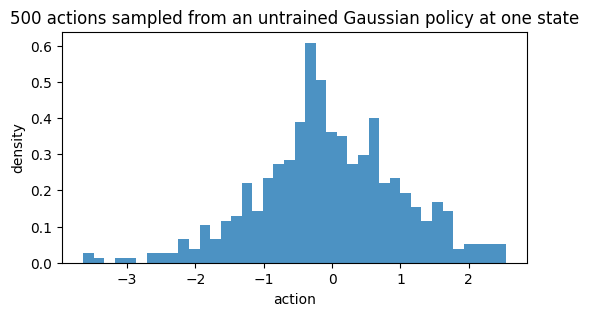

In [5]:
import matplotlib.pyplot as plt

gauss = GaussianPolicy(in_dim=3, act_dim=1)
state = torch.tensor([1.0, 0.0, 0.5])
actions = gauss(state).sample((500,)).squeeze().numpy()

plt.figure(figsize=(6, 3))
plt.hist(actions, bins=40, density=True, alpha=0.8)
plt.xlabel("action"); plt.ylabel("density")
plt.title("500 actions sampled from an untrained Gaussian policy at one state")
plt.show()

### Exploration comes built in

Play with the sliders below: $\mu$ is where the policy aims, $\sigma$ is how much it experiments around that aim. A stochastic policy *is* an exploration strategy.

In [6]:
import numpy as np
from ipywidgets import interact, FloatSlider

@interact(mu=FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.1),
          sigma=FloatSlider(value=1.0, min=0.05, max=2.0, step=0.05))
def show_gaussian_policy(mu=0.0, sigma=1.0):
    xs = np.linspace(-4, 4, 300)
    density = np.exp(-0.5 * ((xs - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
    samples = np.random.default_rng(0).normal(mu, sigma, size=40)
    plt.figure(figsize=(7, 3))
    plt.plot(xs, density, color="C0")
    plt.plot(samples, np.full_like(samples, -0.02), "|", color="C1", markersize=12,
             label="sampled actions")
    plt.xlabel("action"); plt.ylabel("probability density")
    plt.ylim(-0.06, 2.2)
    plt.legend()
    plt.show()

interactive(children=(FloatSlider(value=0.0, description='mu', max=2.0, min=-2.0), FloatSlider(value=1.0, desc…

_Question_. In value-based learning, exploration was an add-on to the actual algorithm ($\epsilon$-greedy with a decay schedule) that we designed by hand. Where does exploration live in a stochastic policy?

_Question_. What happens to the agent's exploration as $\sigma_\theta \to 0$ during training? Who controls $\sigma_\theta$?

## The Objective and Its Gradient

Let's consider a policy-based optimization called **policy gradient (PG)**, where we optimize policy parameters via gradient ascent on the return manifold.

### Why we cannot just backprop on the return

We want the policy that collects the most reward. Writing $\tau = (s_0, a_0, r_0, s_1, \ldots)$ for a trajectory and $R(\tau) = \sum_{t} r_t$ for its return, the objective is

$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}\big[R(\tau)\big],$$

the expected return of running the policy. We would like to do gradient *ascent* on it: $\theta \leftarrow \theta + \eta \nabla_\theta J(\theta)$.

In DQN, the loss was a squared error containing the network output, and backpropagation gave the gradient directly. Here, the situation is fundamentally different. $\theta$ does not appear inside a differentiable formula for $R(\tau)$. **It appears inside the distribution that generates the trajectory** $\tau$. The reward arrives from `env.step`, a black box we cannot differentiate through.

### The log-derivative trick

Write the expectation as an integral over trajectories, with $P(\tau \mid \theta)$ the probability of a trajectory under $\pi_\theta$:

$$\nabla_\theta J(\theta) = \nabla_\theta \int P(\tau \mid \theta)\, R(\tau)\, d\tau = \int \nabla_\theta P(\tau \mid \theta)\, R(\tau)\, d\tau.$$

The integrand is not an expectation anymore, so we cannot estimate it by sampling. The fix is the identity $\nabla P = P \, \nabla \log P$, which gives:

$$\nabla_\theta J(\theta) = \int P(\tau \mid \theta)\, \nabla_\theta \log P(\tau \mid \theta)\, R(\tau)\, d\tau = \mathbb{E}_{\tau \sim \pi_\theta}\big[\nabla_\theta \log P(\tau \mid \theta)\, R(\tau)\big].$$

Now it *is* an expectation under the policy, so trajectories sampled by simply running the policy give an unbiased estimate.

### Model-free policy update

It remains to compute $\nabla_\theta \log P(\tau \mid \theta)$. Using the Markov assumption, the probability of a trajectory neatly factorizes into the initial state distribution, the dynamics, and the policy:

$$\log P(\tau \mid \theta) = \log \left[\rho(s_0) \prod_{t=0}^{T}  P(s_{t+1} \mid s_t, a_t) \pi_\theta(a_t \mid s_t)\right] = \log \rho(s_0) + \sum_{t=0}^{T} \Big[ \log P(s_{t+1} \mid s_t, a_t) + \log \pi_\theta(a_t \mid s_t) \Big].$$

where $\rho$ is the distribution function over initial states. Note that only the policy terms depend on $\theta$. The start distribution and the dynamics are properties of the *environment*, so their gradients with respect to $\theta$ are zero, and they drop out entirely. **This is the moment where "model-free" becomes visible in the algebra**. The unknown dynamics appear in the derivation and then vanish from it. What survives is

$$\boxed{\;\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}\left[ \left( \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t \mid s_t) \right) R(\tau) \right]\;}$$

This is the score-function (likelihood-ratio) estimator behind the REINFORCE algorithm ([Williams, 1992](https://link.springer.com/article/10.1007/BF00992696)); its general form for parametric policies is the **policy gradient theorem** ([Sutton, McAllester, Singh & Mansour, NeurIPS 1999](https://proceedings.neurips.cc/paper/1999/hash/464d828b85b0bed98e80ade0a5c43b0f-Abstract.html)).

This score is interpreted as each trajectory casting a **vote**:
- If its return is positive, increase the log-probability of every action taken along the way. If it is negative, decrease them.
- The magnitude of the score dictates the strength of the vote.

Simply put, actions are reinforced in proportion to how well things went when they were used.

_Question_. In this estimator, the reward $r_5$ collected at step 5 multiplies $\nabla_\theta \log \pi_\theta(a_{20} \mid s_{20})$, the log-probability of an action taken 15 steps *later*. Why is this term wasteful? What is its contribution to the gradient in expectation?

## Seeing the gradient (VaultEnv)

Every deep-learning course shows the algebra above. Almost none *visualize what it means*. For this we create a policy with exactly two parameters, so that $J(\theta)$ is a surface you can plot. No standard environment is compatible with such a small policy (even CartPole with the smallest network has thousands). So, in the spirit of `ForkEnv` that we saw in the previous tutorial, we build the smallest environment that isolates what is special about optimizing *in policy space*.

**VaultEnv.** You stand in a hall. You can take the **exit**, a guaranteed payout of $0.5$, and the episode ends. Or you can **enter the vault**, where two levers await: the right lever pays $1$, the wrong one pays $0$, and either way the episode ends.

![vault](images/vault.png)

Two states (hall, vault), two actions each, episodes of at most two steps. The optimal behavior is obvious: enter, pull the right lever, collect $1$.

### VaultEnv implementation

In [7]:
from gymnasium import spaces


class VaultEnv(gym.Env):
    """Hall (state 0): action 0 = take the exit -> terminal, reward 0.5;
    action 1 = enter the vault -> state 1, reward 0.
    Vault (state 1): action 1 = right lever -> reward 1; action 0 = wrong
    lever -> reward 0; both terminal. Optimal return is 1."""

    EXIT_REWARD = 0.5

    def __init__(self):
        super().__init__()
        self.observation_space = spaces.Discrete(2)
        self.action_space = spaces.Discrete(2)
        self.state = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = 0
        return self.state, {}

    def step(self, action):
        if self.state == 0:
            if action == 0:                                   # take the exit
                return self.state, self.EXIT_REWARD, True, False, {}
            self.state = 1                                    # enter the vault
            return self.state, 0.0, False, False, {}
        return self.state, float(action == 1), True, False, {}

### Minimal policy

We give it the smallest possible stochastic policy with one parameter per state,

$$\pi_\theta(\text{enter} \mid \text{hall}) = \sigma(\theta_0), \qquad \pi_\theta(\text{right lever} \mid \text{vault}) = \sigma(\theta_1),$$

with $\sigma$ the sigmoid. Because the environment is tiny we can compute the objective *exactly* by enumerating the three outcomes (exit, enter-and-win, enter-and-lose):

$$J(\theta) = \big(1 - \sigma(\theta_0)\big) \cdot 0.5 + \sigma(\theta_0)\,\sigma(\theta_1) \cdot 1 = 0.5 + \sigma(\theta_0)\big(\sigma(\theta_1) - 0.5\big),$$

and differentiating by hand gives the exact gradient. No sampling, no estimates; this is the true $J$ and the true $\nabla J$ that all our estimators will be chasing.

In [8]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def J_exact(theta0, theta1):
    s0, s1 = sigmoid(theta0), sigmoid(theta1)
    return (1 - s0) * VaultEnv.EXIT_REWARD + s0 * s1

def grad_J_exact(theta0, theta1):
    s0, s1 = sigmoid(theta0), sigmoid(theta1)
    dJ_d0 = s0 * (1 - s0) * (s1 - VaultEnv.EXIT_REWARD)  # sigmoid' = s(1-s)
    dJ_d1 = s0 * s1 * (1 - s1)
    return dJ_d0, dJ_d1

### Visualizing 2-param policy gradients

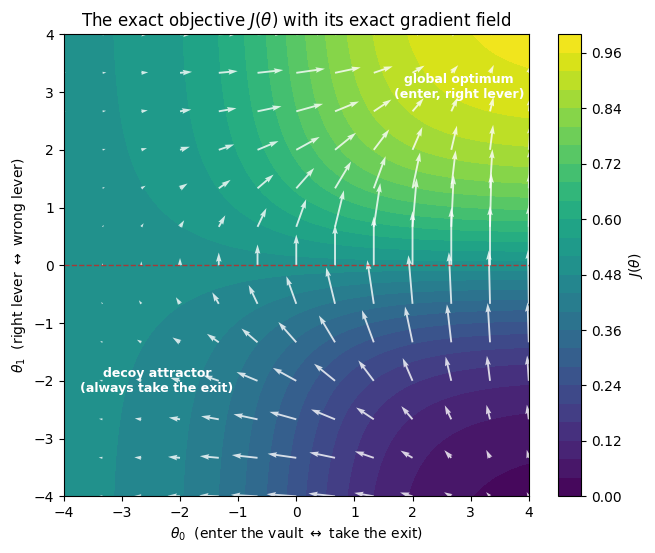

In [9]:
from utils import plot_vault_landscape

plt.figure(figsize=(7.5, 6))
plot_vault_landscape(J_exact, grad=grad_J_exact)
plt.title("The exact objective $J(\\theta)$ with its exact gradient field")
plt.show()

Read the picture. The bright upper-right corner is the optimum: enter ($\sigma(\theta_0) \to 1$) and pull the right lever ($\sigma(\theta_1) \to 1$), $J \to 1$. But look at the arrows below the dashed line, where $\sigma(\theta_1) < 0.5$. There the vault is a worse bet than the exit, entering pays $\sigma(\theta_1)$ in expectation versus a guaranteed $0.5$, so the gradient on $\theta_0$ points **left**: stop entering. And the flow does converge there: the entire left edge, with $\theta_1$ below the line, is a **decoy attractor** where the policy always takes the exit and $J$ plateaus at $0.5$, half the optimum.

The decoy is not just suboptimal, it is **self-sealing**. Look at the gradient for the lever parameter:

$$\frac{\partial J}{\partial \theta_1} = \sigma(\theta_0)\, \sigma(\theta_1)\big(1 - \sigma(\theta_1)\big).$$

It is proportional to $\sigma(\theta_0)$, the probability of entering the vault at all. As the policy stops entering, the gradient that could improve its lever skill **vanishes**. A policy only learns about the states it visits. If it improves by avoiding somewhere, it also stops learning there.

This landscape also tells us something fundamental about optimizing in policy space: $J(\theta)$ is in general **non-concave in the policy parameters**, with suboptimal attractors, even for an MDP this small (for the general theory, see [Agarwal, Kakade, Lee & Mahajan, 2021](https://jmlr.org/papers/v22/19-736.html)). Where gradient ascent ends up depends on where it starts.

### Does value-based learning see the same trap?

_Question_. Take tabular Q-learning and run it on VaultEnv from many different random initializations of the Q-table. What set of outcomes do you expect? Now run gradient ascent on $J(\theta)$ from many random initializations of $\theta$. What accounts for the difference?

Let's actually run both. Gradient ascent here uses the *exact* gradient, the best case for the policy method: any failure is the landscape's fault, not an estimator's. We write the ascent loop to take the gradient as a function argument, because later we will swap in noisy sampled gradients and reuse it unchanged.

In [10]:
def ascend(theta_start, grad_fn, lr=2.0, n_steps=300):
    # plain gradient ascent, recording the path through parameter space
    theta = np.array(theta_start, dtype=float)
    traj = [theta.copy()]
    for _ in range(n_steps):
        theta = theta + lr * np.array(grad_fn(theta))
        traj.append(theta.copy())
    return np.array(traj)

exact_grad = lambda th: grad_J_exact(th[0], th[1])

In [11]:
from utils import tabular_q_learning, greedy_policy, plot_trajectories

n_inits = 20
rng_init = np.random.default_rng(10)

q_optimal = 0
pg_trajs = []
for i in range(n_inits):
    # Q-learning from a random Q-table (Tut06 algorithm, epsilon-greedy exploration)
    q = tabular_q_learning(VaultEnv(), n_episodes=1000, epsilon=0.3, alpha=0.2,
                           q_init_scale=2.0, seed=i)
    q_optimal += bool((greedy_policy(q) == [1, 1]).all())

    # exact-gradient ascent from a random theta
    pg_trajs.append(ascend(rng_init.normal(0.0, 2.0, size=2), exact_grad))

pg_returns = np.array([J_exact(*tr[-1]) for tr in pg_trajs])
pg_optimal = int((pg_returns > 0.75).sum())
print(f"Q-learning:              optimal policy from {q_optimal}/{n_inits} random initializations")
print(f"exact policy gradient:   optimal policy from {pg_optimal}/{n_inits} random initializations")

Q-learning:              optimal policy from 20/20 random initializations
exact policy gradient:   optimal policy from 15/20 random initializations


Q-learning reaches the optimal policy from **every** initialization, while gradient ascent on $J$, following the *exact* gradient with no noise at all, walks into the decoy from a solid fraction of starts. Same MDP, two different fates.

The Bellman backup is a contraction with a **single fixed point**. Whatever the initial table, the iterations pull toward the same $Q^*$, so there are no basins and nowhere to get stuck. And its $\epsilon$-greedy behavior keeps visiting the vault no matter how unpromising the current estimates look, so the backup eventually learns that the right lever is worth $1$, and the $\max$ does the rest. This is why it is immune to such traps.

### Visualize gradient ascent

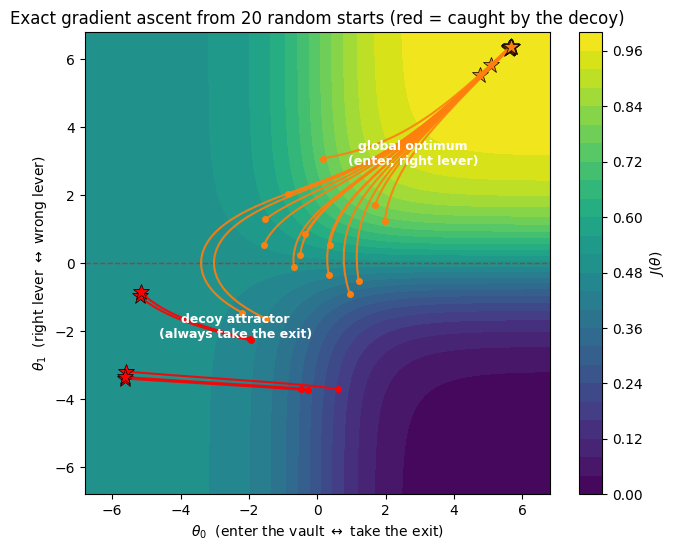

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 6))
plot_vault_landscape(J_exact, lim=6.8, ax=ax)   # wider view: ascent overshoots [-4, 4]
plot_trajectories([tr for tr, r in zip(pg_trajs, pg_returns) if r > 0.75], ax, color="C1")
plot_trajectories([tr for tr, r in zip(pg_trajs, pg_returns) if r <= 0.75], ax, color="red")
ax.set_title("Exact gradient ascent from 20 random starts (red = caught by the decoy)")
plt.show()

So the trap is not a property of the MDP, it is a property of the **policy-space landscape**, and only the method that optimizes in that landscape can fall into it. Value-based and policy-based methods do not just differ in what they represent. They climb different surfaces.

## Estimating the gradient from samples

In VaultEnv we can enumerate outcomes, so the gradient is exact. In any real environment we cannot, and this is where the boxed formula earns its keep: run the policy, collect trajectories, and average

$$\hat g = \frac{1}{N} \sum_{i=1}^{N} \left( \sum_{t} \nabla_\theta \log \pi_\theta(a^i_t \mid s^i_t) \right) R(\tau^i)$$

over a batch of $N$ episodes. For our two-parameter policy the per-step scores have a closed form, $\frac{\partial}{\partial \theta} \log \sigma(\theta) = 1 - \sigma(\theta)$ for the taken action (and $-\sigma(\theta)$ for the other one), so a few lines implement the estimator.

In [13]:
def vault_episode(theta, rng):
    # play one episode of VaultEnv under the 2-parameter policy;
    # return (episode return, sum over steps of grad-log-prob of the taken action)
    s0, s1 = sigmoid(theta[0]), sigmoid(theta[1])
    glog = np.zeros(2)

    enter = rng.random() < s0                     # hall decision, P(enter) = sigma(theta0)
    glog[0] = (1 - s0) if enter else -s0          # d/dtheta0 log pi(a0 | hall)
    if not enter:
        return VaultEnv.EXIT_REWARD, glog

    right = rng.random() < s1                     # vault decision, P(right) = sigma(theta1)
    glog[1] = (1 - s1) if right else -s1          # d/dtheta1 log pi(a1 | vault)
    return float(right), glog


def vault_grad_estimate(theta, batch_size, rng, baseline=0.0):
    # the REINFORCE estimator: average of grad-log-prob * (return - baseline)
    g = np.zeros(2)
    for _ in range(batch_size):
        R, glog = vault_episode(theta, rng)
        g += (R - baseline) * glog
    return g / batch_size

### Unbiased gradient estimator

As with Monte Carlo control, the theory says that this estimator is **unbiased**: averaged over enough episodes it equals the exact gradient. That is a claim we can simply test since we have the exact gradient sitting right there.

In [14]:
rng = np.random.default_rng(0)
theta_probe = np.array([0.0, 1.0])   # a point in the good basin, gradient clearly nonzero

estimates = np.array([vault_grad_estimate(theta_probe, 1, rng) for _ in range(100_000)])
print("exact gradient:            ", np.round(grad_J_exact(*theta_probe), 4))
print("mean of 100k 1-episode est:", np.round(estimates.mean(axis=0), 4))

exact gradient:             [0.0578 0.0983]
mean of 100k 1-episode est: [0.0584 0.0987]


Unbiased indeed!

### Unbiased... but noisy!

The mean is not the whole story. Below, each dot is one gradient *estimate* $\hat g$ at the same fixed $\theta$, exactly what a training step would use. The black arrow is the truth and the colored arrow is the empirical mean of the dots. Change the batch size $N$ to see its effect.

In [15]:
from utils import plot_gradient_samples

true_g = np.array(grad_J_exact(*theta_probe))
batch_sizes = [1, 4, 16, 64, 256]
rng = np.random.default_rng(1)
clouds = {N: np.array([vault_grad_estimate(theta_probe, N, rng) for _ in range(200)])
          for N in batch_sizes}
cloud_lim = float(np.abs(clouds[1]).max()) * 1.05   # fixed axes across batch sizes

@interact(batch_size=batch_sizes)
def show_gradient_cloud(batch_size=1):
    plt.figure(figsize=(5.8, 5.8))
    plot_gradient_samples(clouds[batch_size], true_g, lim=cloud_lim,
                          label=f"200 estimates, batch size {batch_size}")
    plt.title(f"Gradient estimates at a fixed $\\theta$ (batch size {batch_size})")
    plt.legend(loc="upper left")
    plt.show()

interactive(children=(Dropdown(description='batch_size', options=(1, 4, 16, 64, 256), value=1), Output()), _do…

This is the picture to remember: **unbiased but noisy**. At small batch sizes the point cloud is enormous relative to the true arrow, individual estimates routinely point sideways or backwards, yet the cloud is centered on the truth, and growing the batch shrinks it (at the usual Monte Carlo rate, standard deviation $\propto 1/\sqrt{N}$). Every policy-gradient method is a walk uphill guided by dots drawn from clouds like this one.

### Ascending a noisy gradient

So what does that noise *do* to the optimization? We reuse the same `ascend` loop, swapping the exact gradient for a single-episode estimate, the extreme case of learning from each episode as it comes.

In [16]:
rng = np.random.default_rng(3)
starts = [(-2.5, -1.0), (-1.5, -2.0), (0.0, -1.5), (2.0, -2.0), (-2.0, 1.0),
          (0.5, -0.5), (-1.0, -3.0), (1.5, -3.0), (-2.5, 2.5), (1.0, 0.5)]

@interact(batch_size=batch_sizes)
def compare_batch_to_exact(batch_size=1):
    sampled_grad = lambda th: vault_grad_estimate(th, batch_size, rng)
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))
    for ax, grad_fn, title in [(axes[0], exact_grad, "exact gradient"),
                               (axes[1], sampled_grad, "sampled gradient (batch size 1)")]:
        trajs = [ascend(s, grad_fn) for s in starts]
        rets = [J_exact(*tr[-1]) for tr in trajs]
        plot_vault_landscape(J_exact, lim=6.8, ax=ax, cbar=False, annotate=False)
        plot_trajectories([t for t, r in zip(trajs, rets) if r > 0.75], ax, color="C1")
        plot_trajectories([t for t, r in zip(trajs, rets) if r <= 0.75], ax, color="red")
        n_trap = sum(r <= 0.75 for r in rets)
        ax.set_title(f"{title}: {n_trap}/{len(starts)} caught by the decoy")
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='batch_size', options=(1, 4, 16, 64, 256), value=1), Output()), _do…

_Question_: Compare the two panels start by start (they begin at the same points). The exact trajectories are smooth and their fate is fully decided by the starting point. What is different about the sampled ones, in the paths they take and in where they end up?

### Trap statistics

Let's quantify instead of eyeballing. Sweep a grid of starting points and count how often each optimizer ends in the decoy.

In [17]:
grid = np.linspace(-3, 3, 9)
rng = np.random.default_rng(5)

def trap_fraction(grad_fn, reps=1):
    # fraction of grid starts (repeated reps times for the noisy variants)
    # whose ascent ends in the decoy
    starts_grid = [(t0, t1) for t0 in grid for t1 in grid] * reps
    trapped = sum(J_exact(*ascend(s, grad_fn)[-1]) < 0.75 for s in starts_grid)
    return trapped / len(starts_grid)

print(f"exact      trapped in the decoy from {trap_fraction(exact_grad):5.1%} of starts")
print(f"batch=64   trapped in the decoy from "
      f"{trap_fraction(lambda th: vault_grad_estimate(th, 64, rng), reps=5):5.1%} of starts")
print(f"batch=1    trapped in the decoy from "
      f"{trap_fraction(lambda th: vault_grad_estimate(th, 1, rng), reps=5):5.1%} of starts")

exact      trapped in the decoy from 13.6% of starts
batch=64   trapped in the decoy from 13.6% of starts
batch=1    trapped in the decoy from 25.7% of starts


The noise is not a neutral slowdown. A batch of 64 behaves almost like the exact flow, but at batch size 1 the fraction of runs caught by the decoy roughly **doubles**. Every episode that takes the exit collects a positive return of $0.5$ and therefore *reinforces taking the exit*, the estimator pushes up the log-probability of whatever was done whenever the return is positive. Only the occasional enter-and-win episode pushes back.

## REINFORCE

Time to scale from two parameters to a neural network. The recipe is exactly the boxed formula turned into a loop, first published as REINFORCE ([Williams, 1992](https://link.springer.com/article/10.1007/BF00992696)), also called **Monte Carlo policy gradient**. Like the Monte Carlo methods of Tut06, it waits for complete episodes and uses full returns.

**Algorithm. REINFORCE**

1. Initialize policy parameters $\theta$ at random
2. Repeat:
    1. Run $\pi_\theta$ $N$ episodes, collect batch of trajectories and returns.
    2. Compute $L(\theta) = -\frac{1}{N}\sum_{\tau}\sum_t \log \pi_\theta(a_t \mid s_t)\, R(\tau)$
    3. Take one gradient step on $L(\theta)$
    4. **Discard the batch** and collect a fresh one

Step D looks innocent. Keep it in the back of your mind and we will circle back to it later.

### A "loss" that is not a loss

REINFORCE minimizes the value:
$$L(\theta) = -\frac{1}{N}\sum_{\tau}\sum_t \log \pi_\theta(a_t \mid s_t)\, R(\tau)$$
The quantity $L(\theta)$ is **not a loss function** in the same sense as in DQN. The TD loss measured something, a prediction error we genuinely wanted to be small. This $L(\theta)$ measures nothing. It is a construction whose only property is that its gradient equals $-\nabla_\theta J(\theta)$. Its value is meaningless, it can go up as the policy improves, and driving it to $-\infty$ on a *fixed* batch would just mean inflating the probabilities of whatever happened to be in the batch. **Do not monitor it, do not early-stop on it**. The only number that means anything is the return.

### Implement for Gymnasium

First, collecting one episode. Note this is the *only* place the agent touches the environment, and the only thing we keep is what the update needs: log-probabilities (with their gradient graphs) and rewards.

In [18]:
from gymnasium.spaces import Discrete

def collect_episode(env, policy, seed=None):
    obs, _ = env.reset(seed=seed)
    log_probs, rewards = [], []
    done = False
    while not done:
        dist = policy(torch.as_tensor(obs, dtype=torch.float32))
        a = dist.sample()                       # exploration = sampling the policy
        log_probs.append(dist.log_prob(a).sum())  # keep the differentiable log-prob
        # a Categorical action is an int for the env; a Gaussian action is a vector
        act = int(a.item()) if isinstance(dist, torch.distributions.Categorical) else a.numpy()
        obs, r, term, trun, _ = env.step(act)
        rewards.append(float(r))
        done = term or trun
    return log_probs, rewards


def make_policy(env):
    # the only environment-specific choice: which distribution head to attach
    if isinstance(env.action_space, Discrete):
        return CategoricalPolicy(env.observation_space.shape[0], env.action_space.n)
    return GaussianPolicy(env.observation_space.shape[0], env.action_space.shape[0])

And the training loop.

In [19]:
from tqdm.auto import tqdm
from utils import set_seed

def train_reinforce(env, n_iters=150, batch_size=8, lr=5e-3, seed=0, policy=None):
    set_seed(seed)
    if policy is None:
        policy = make_policy(env)
    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)

    history = []      # one (episode index, cumulative env steps, return) per episode
    env_steps = 0
    for it in tqdm(range(n_iters), leave=False):
        batch_log_probs, batch_weights = [], []
        for ep in range(batch_size):
            log_probs, rewards = collect_episode(env, policy, seed=seed + len(history))
            R = sum(rewards)
            env_steps += len(rewards)
            history.append((len(history), env_steps, R))
            batch_log_probs += log_probs
            batch_weights += [R] * len(log_probs)   # every action gets the whole-episode return

        weights = torch.tensor(batch_weights, dtype=torch.float32)
        # the REINFORCE "loss": its gradient is minus the policy gradient
        loss = -(torch.stack(batch_log_probs) * weights).sum() / batch_size
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return history, policy

### REINFORCE on CartPole

We run REINFORCE on CartPole for four seeds, same environment and same network size as we did for DQN.

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

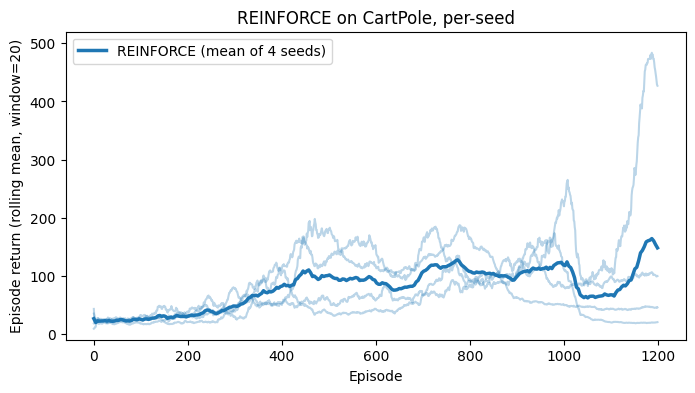

In [20]:
from utils import plot_seed_curves

env = gym.make("CartPole-v1")
n_seeds = 4

reinforce_runs = []
for seed in tqdm(range(n_seeds)):
    hist, _ = train_reinforce(env, seed=seed)
    reinforce_runs.append(hist)

plt.figure(figsize=(8, 4))
plot_seed_curves([[(ep, r) for ep, _, r in h] for h in reinforce_runs],
                 color="C0", label="REINFORCE (mean of 4 seeds)")
plt.xlabel("Episode")
plt.ylabel("Episode return (rolling mean, window=20)")
plt.title("REINFORCE on CartPole, per-seed")
plt.ylim(-10, 520)
plt.legend(loc="upper left")
plt.show()

It learns, the returns climb well above the random-policy baseline of ~20, so the estimator is clearly pointing uphill on average. But the training curves tell a disappointing story:
- The ascent is slow
- Performance disagrees greatly across seeds
- Performance collapses (a seed that reached a few hundred can be back near 50 a hundred episodes later).

_Question_: The network architecture, the environment, and the optimizer are the same as in our DQN runs. What is different about the *gradient signal* the optimizer receives that could explain these training curves compared to DQN?

We do not have to speculate. The VaultEnv scatter plot showed us exactly what a policy-gradient estimate looks like, a dot from a wide cloud. Time to measure the cloud on CartPole itself.

## Variance: PG's nemesis

"High variance" is the standard complaint about policy gradients; courses usually assert it and move on. We will measure it. The plan:

1. Freeze a reference policy $\pi$ partway through training (interesting gradients live there; at convergence the true gradient is $\approx 0$ and there is nothing to measure).
2. Compute the single-episode gradient estimate $\hat g$ many times, each from one fresh episode.
3. Quantify the noise relative to the signal. The *signal* is the average estimate $\bar g$, which we know points along the true gradient; the *noise* is how far one individual estimate typically lands from that average:
$$\text{relative noise} = \frac{\mathbb{E}\, \lVert \hat g - \bar g \rVert}{\lVert \bar g \rVert}.$$
This is interpreted as "the error in a one-episode estimate is this many times longer than the signal it carries."

### Measuring noise in CartPole

In [21]:
# a reference policy from early in training (average return around 50)
probe_env = gym.make("CartPole-v1")
_, probe_policy = train_reinforce(probe_env, n_iters=30, seed=1)

probe_params = list(probe_policy.parameters())

def flat_grad(loss):
    # gradient of a scalar loss w.r.t. the policy parameters, flattened to one vector
    gs = torch.autograd.grad(loss, probe_params, retain_graph=True)
    return torch.cat([g.flatten() for g in gs]).numpy()

# collect the probe episodes once; every estimator variant will reuse the same episodes
n_probe = 400
probe_episodes = [collect_episode(probe_env, probe_policy, seed=100_000 + i)
                  for i in tqdm(range(n_probe))]
probe_returns = [sum(rw) for _, rw in probe_episodes]
print(f"reference policy average return: {np.mean(probe_returns):.0f}")

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/400 [00:00<?, ?it/s]

reference policy average return: 52


In [22]:
# one gradient estimate per episode, using the whole-episode return as the weight
grads_vanilla = []
for log_probs, rewards in tqdm(probe_episodes):
    R = sum(rewards)
    loss = -(torch.stack(log_probs) * R).sum()
    grads_vanilla.append(flat_grad(loss))
grads_vanilla = np.asarray(grads_vanilla)

mean_g = grads_vanilla.mean(axis=0)
rel_noise = np.linalg.norm(grads_vanilla - mean_g, axis=1).mean() / np.linalg.norm(mean_g)
print(f"relative noise of the single-episode estimate: {rel_noise:.1f}")

  0%|          | 0/400 [00:00<?, ?it/s]

relative noise of the single-episode estimate: 8.7


What do these numbers mean? Decompose a single-episode estimate into signal and error,

$$\hat g = \underbrace{\bar g}_{\text{signal}} \; + \; \underbrace{(\hat g - \bar g)}_{\text{error}},$$

- The measurement says the error part is typically about **nine times longer** than the signal part.
- A one-episode gradient estimate is not "the gradient, plus some noise", it is "mostly noise, with a whisper of gradient folded in".

Training works anyway because over many updates the errors average out while the whisper always points the same way, but any single update is dominated by luck.

### The signal is buried in the noise

The histogram below turns the same measurement into a single number per estimate. For each $\hat g$ we plot its **uphill component**: the projection $\hat g \cdot \bar g / \lVert \bar g \rVert$ of the estimate onto the direction of the mean gradient. If this component is positive, a small update step along $\hat g$ would (to first order) *increase* $J$. If it is **negative, taking that single-episode update would actually move the policy downhill**.

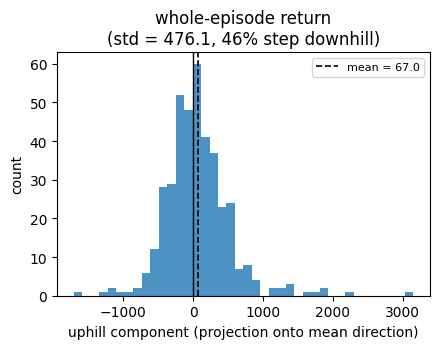

In [23]:
from utils import plot_probe_histograms

# reference direction for all the histograms in this section
ref_dir = mean_g / np.linalg.norm(mean_g)

projections = {"whole-episode return": grads_vanilla @ ref_dir}
plot_probe_histograms(projections)

Nearly **half** of single-episode updates would move the policy downhill. That is what a signal-to-noise ratio of $\approx 0.14$ looks like (a mean projection of $\approx 67$ against a standard deviation of $\approx 476$). The histogram straddles zero, and the entire learning signal is the slight rightward shift of its center. Training still works because that shift is real and persistent while the errors cancel over time, but every individual step is a lottery, which is exactly the jitter and the collapses we saw in the learning curves, and, as VaultEnv warned us, in a landscape with traps, the lottery can decide the destination.

## Fix 1: Reward-to-Go

The estimator multiplies $\nabla_\theta \log \pi_\theta(a_t \mid s_t)$ by the return of the *whole* episode, including rewards collected **before** step $t$. But an action cannot influence rewards that were already received. Causality only runs forward.

Formally, note that:

$$\mathbb{E}_{a \sim \pi_\theta(\cdot \mid s)}\big[ \nabla_\theta \log \pi_\theta(a \mid s) \big] \;=\; \sum_a \pi_\theta(a \mid s)\, \frac{\nabla_\theta \pi_\theta(a \mid s)}{\pi_\theta(a \mid s)} \;=\; \nabla_\theta \sum_a \pi_\theta(a \mid s) \;=\; \nabla_\theta\, 1 \;=\; 0.$$

When conditioned on the past, $r_{t'}$ is constant for any $t' < t$ and thus:

$$\mathbb{E}\big[ \nabla_\theta \log \pi_\theta(a_t \mid s_t)\; r_{t'} \big] = \mathbb{E}\big[ \nabla_\theta \log \pi_\theta(a_t \mid s_t)\big] \mathbb{E}\big[r_{t'} \big] = 0$$

Terms with zero mean contribute nothing to the gradient, but they do contribute variance, pure noise, for free. Dropping them leaves each action weighted only by what came after it:

$$\nabla_\theta J(\theta) = \mathbb{E}\left[ \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t \mid s_t)\, \underbrace{\sum_{t' = t}^{T} r_{t'}}_{\hat R_t,\ \text{the reward-to-go}} \right].$$

The causality argument is stated in exactly this form by [Peters & Schaal (2008)](https://www.ias.informatik.tu-darmstadt.de/uploads/Publications/Publications/Neural-Netw-2008-21-682_4867%5B0%5D.pdf), who trace the resulting estimator to the GPOMDP algorithm of [Baxter & Bartlett (2001)](https://arxiv.org/abs/1106.0665). The name "reward-to-go" is from [OpenAI Spinning Up](https://spinningup.openai.com/en/latest/spinningup/rl_intro3.html), whose presentation we follow.

In [24]:
def rewards_to_go(rewards, gamma=1.0):
    # backward pass: rtg[t] = r[t] + gamma * rtg[t+1]
    rtg = np.zeros(len(rewards))
    running = 0.0
    for t in reversed(range(len(rewards))):
        running = rewards[t] + gamma * running
        rtg[t] = running
    return rtg

# a 4-step episode: the whole-episode return is 10, but later actions
# are only credited with what they could still influence
print(rewards_to_go([1.0, 2.0, 3.0, 4.0]))

[10.  9.  7.  4.]


### Noise with reward-to-go

  0%|          | 0/400 [00:00<?, ?it/s]

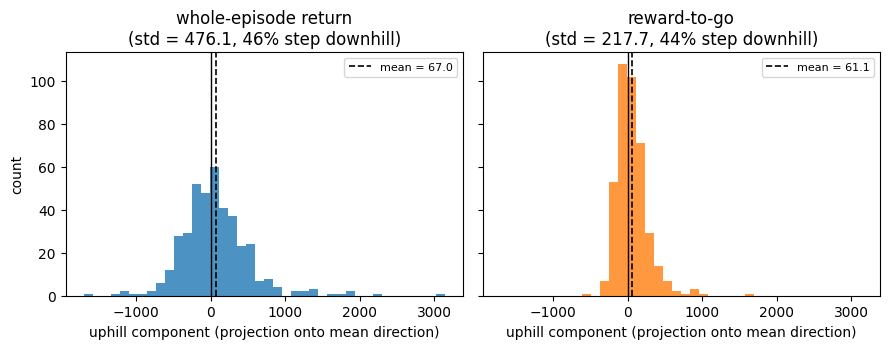

In [25]:
grads_rtg = []
for log_probs, rewards in tqdm(probe_episodes):
    rtg = torch.tensor(rewards_to_go(rewards), dtype=torch.float32)
    loss = -(torch.stack(log_probs) * rtg).sum()
    grads_rtg.append(flat_grad(loss))
grads_rtg = np.asarray(grads_rtg)

projections["reward-to-go"] = grads_rtg @ ref_dir
plot_probe_histograms(projections)

Same mean, and less than half the spread, all from *deleting* terms. This fix costs nothing: no extra samples, no extra parameters, one cumulative sum.

## Fix 2: Baselines

On CartPole every return is positive, so
- *every* trajectory votes to increase the probability of everything it did. Bad episodes are reinforced too, just less.
- Learning then relies on the softmax renormalizing "increased a little" into "relatively suppressed", which works, slowly and noisily.

What we would rather do is grade on a curve, i.e., reinforce what was **better than expected**, suppress what was worse.

The idea is simple: subtracting any constant $b$ from the weights does not change the expected gradient. Recall that

$$\mathbb{E}_{a \sim \pi_\theta(\cdot \mid s)}\big[ \nabla_\theta \log \pi_\theta(a \mid s) \big] \;=\; 0.$$

Thus, when multiplying by a constant, the expected score is still zero, so $\mathbb{E}[\nabla \log \pi \cdot b] = b \cdot 0 = 0$ for any $b$ that does not depend on the action. As a result:

$$\nabla_\theta J(\theta) = \mathbb{E}\left[ \sum_t \nabla_\theta \log \pi_\theta(a_t \mid s_t) \big( \hat R_t - b \big) \right]$$

holds for every constant **baseline** $b$.

The mean is untouched, the variance is not, and a well-chosen $b$ reduces it substantially.

Baselines go back to REINFORCE itself ([Williams, 1992](https://link.springer.com/article/10.1007/BF00992696)). The modern analysis views them as *control variates*, the classical Monte Carlo variance-reduction device ([Greensmith, Bartlett & Baxter, 2004](https://jmlr.org/papers/volume5/greensmith04a/greensmith04a.pdf)), the same Monte Carlo toolbox we have been drawing on since Tut05.

### Baselines are unbiased on VaultEnv

Unbiasedness is a mathematical claim. Let's use VaultEnv to *check* this claim against exact answers. Same fixed $\theta$ as before, same estimator (batches of 8 episodes, so the clouds are visible), with and without the baseline $b = \mathbb{E}[R]$ (which we can compute exactly here, it is $J(\theta)$). If the theory is right, the two clouds should share a center and differ in size.

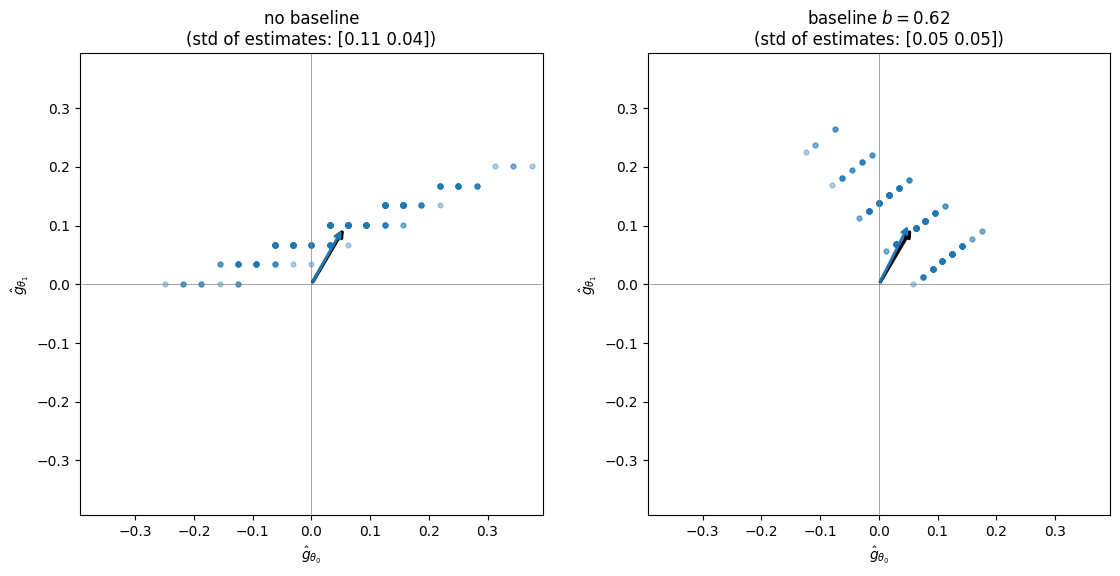

In [26]:
rng = np.random.default_rng(2)
b_vault = J_exact(*theta_probe)      # the expected return, an ideal constant baseline

cloud_no_b = np.array([vault_grad_estimate(theta_probe, 8, rng, baseline=0.0)
                       for _ in range(300)])
cloud_with_b = np.array([vault_grad_estimate(theta_probe, 8, rng, baseline=b_vault)
                         for _ in range(300)])

lim = float(np.abs(cloud_no_b).max()) * 1.05
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.6))
for ax, cloud, title in [(axes[0], cloud_no_b, "no baseline"),
                         (axes[1], cloud_with_b, f"baseline $b = {b_vault:.2f}$")]:
    plt.sca(ax)
    plot_gradient_samples(cloud, true_g, ax=ax, lim=lim)
    ax.set_title(f"{title}\n(std of estimates: {cloud.std(axis=0).round(2)})")
plt.tight_layout()
plt.show()

Exactly as promised! The colored mean arrows agree with the black exact gradient in both panels, **the baseline did not bias anything**, and the right cloud is visibly tighter, especially along $\theta_0$. That horizontal direction is precisely the exit-reinforcement noise we diagnosed earlier. Without a baseline, every exit episode pushes $\theta_0$ down with weight $+0.5$. With $b \approx \mathbb{E}[R]$, the exit's weight becomes $0.5 - b < 0$, "worse than expected", and the estimator stops reinforcing it.

### Average reward-to-go baseline

Back to the CartPole probe for the third histogram. Any constant is a legal baseline, so which constant should we use?

The weights being corrected are the reward-to-go values, one per *timestep*, so the natural yardstick is the **average of those same weights**:
- pool the reward-to-go of every step of every episode in the batch
- take the mean.

For the reference policy below, $b \approx 33$, i.e.,  a typical step of a typical episode under this policy goes on to collect about $33$ more reward. A step that went on to collect $50$ therefore gets weight $+17$ (better than typical, reinforce it), a step that went on to collect $10$ gets weight $-23$ (worse than typical, suppress it). Grading on a curve, with the curve set by the batch itself.

Two remarks on this choice.

- **The baseline must live on the same scale as the weights it corrects.** A tempting alternative is the average episode return ($\approx 52$ for this policy). But a return is a sum over a whole episode, systematically larger than a typical per-step reward-to-go. Subtract it and nearly every weight goes negative, so the update suppresses almost everything it saw.
- **It adapts.** Recomputed every batch, $b$ rises as the policy improves, so "better than expected" keeps meaning better than the *current* policy's typical outcome, not better than some frozen constant from early training.

### CartPole noise reduction with baseline

  0%|          | 0/400 [00:00<?, ?it/s]

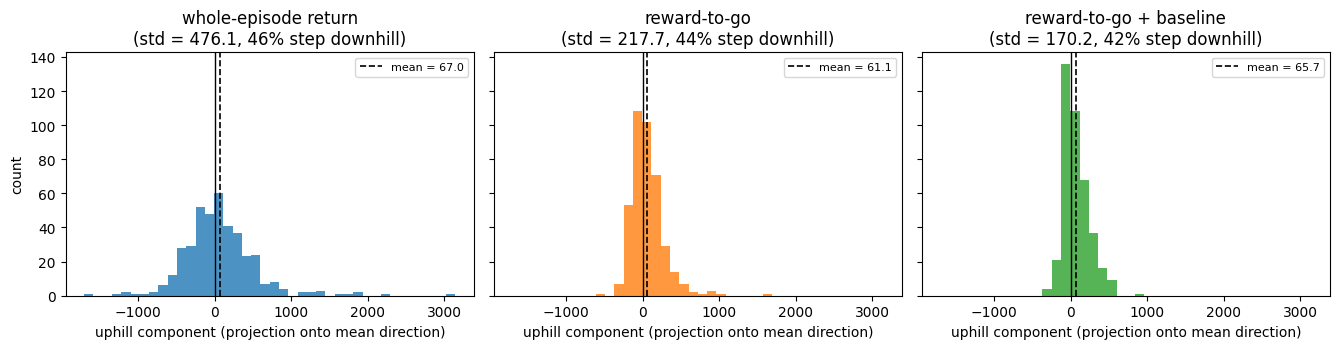

In [27]:
b = np.concatenate([rewards_to_go(rw) for _, rw in probe_episodes]).mean()

grads_rtg_b = []
for log_probs, rewards in tqdm(probe_episodes):
    rtg = torch.tensor(rewards_to_go(rewards) - b, dtype=torch.float32)
    loss = -(torch.stack(log_probs) * rtg).sum()
    grads_rtg_b.append(flat_grad(loss))
grads_rtg_b = np.asarray(grads_rtg_b)

projections["reward-to-go + baseline"] = grads_rtg_b @ ref_dir
plot_probe_histograms(projections)

Three estimators of the *same* expectation: means in agreement, and the spread cut to roughly a third going left to right. We cut the variance twice without paying a single extra episode for it.

### Analysis of noise improvements

Notice how the downhill fraction only reduced from $\approx 46\%$ to $\approx 42\%$. This is because the downhill fraction depends on the signal-to-noise ratio of a *single-episode* estimate, which our fixes raised from $\approx 0.14$ to $\approx 0.39$, better, but still well below $1$, and no reweighting can turn one episode into a sharp measurement of a whole policy's gradient. What finishes the job is something the training loop has been doing all along: **batching**. Averaging $N$ independent estimates leaves the mean untouched and shrinks the noise by $\sqrt{N}$, so **the estimator fixes and the batch size multiply**. Concretely, with our training batch size of $8$:

In [28]:
# the same 400 single-episode estimates, averaged in disjoint batches of 8
for name, grads in [("whole-episode return", grads_vanilla),
                    ("reward-to-go", grads_rtg),
                    ("reward-to-go + baseline", grads_rtg_b)]:
    proj = grads @ ref_dir
    batched = proj.reshape(-1, 8).mean(axis=1)      # 50 batch-of-8 estimates
    print(f"{name:26s} downhill fraction: single episode {np.mean(proj < 0):4.0%}"
          f"  ->  batch of 8 {np.mean(batched < 0):4.0%}")

whole-episode return       downhill fraction: single episode  46%  ->  batch of 8  36%
reward-to-go               downhill fraction: single episode  44%  ->  batch of 8  20%
reward-to-go + baseline    downhill fraction: single episode  42%  ->  batch of 8  12%


This is far more decisive and becomes even more so as the batch size increases.

## Putting the fixes together

We extend the trainer with both fixes behind flags. Only the weight computation changes (marked); everything else is `train_reinforce` verbatim. The `normalize` flag additionally rescales the weights to unit standard deviation, a practical trick we will not need until Pendulum.

In [29]:
def train_reinforce_full(env, n_iters=150, batch_size=8, lr=5e-3, gamma=1.0,
                         reward_to_go=False, baseline=False, normalize=False,
                         seed=0, policy=None):
    set_seed(seed)
    if policy is None:
        policy = make_policy(env)
    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)

    history = []
    env_steps = 0
    for it in tqdm(range(n_iters), leave=False):
        batch_log_probs, batch_weights = [], []
        for ep in range(batch_size):
            log_probs, rewards = collect_episode(env, policy, seed=seed + len(history))
            R = sum(rewards)
            env_steps += len(rewards)
            history.append((len(history), env_steps, R))
            batch_log_probs += log_probs
            # CHANGED: Fix 1, weight each action by what followed it
            if reward_to_go:
                batch_weights += list(rewards_to_go(rewards, gamma))
            else:
                batch_weights += [R] * len(log_probs)

        weights = torch.tensor(np.asarray(batch_weights), dtype=torch.float32)
        # CHANGED: Fix 2, constant baseline = the average weight in the batch
        if baseline:
            weights = weights - weights.mean()
        # practical trick for wild reward scales (used on Pendulum later)
        if normalize:
            weights = weights / (weights.std() + 1e-8)

        loss = -(torch.stack(batch_log_probs) * weights).sum() / batch_size
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return history, policy

### Training on CartPole

The same CartPole training as before, three configurations, vanilla, reward-to-go, and reward-to-go plus baseline, four seeds each, identical budgets. Cached, since it is a few minutes of compute.

In [30]:
from pathlib import Path
from utils import load_or_run

cache_dir = Path("cache")

variants = {
    "vanilla": dict(),
    "reward-to-go": dict(reward_to_go=True),
    "reward-to-go + baseline": dict(reward_to_go=True, baseline=True),
}

def run_variant_sweep():
    results = {}
    for name, kwargs in variants.items():
        results[name] = [train_reinforce_full(gym.make("CartPole-v1"), seed=s, **kwargs)[0]
                         for s in tqdm(range(n_seeds), desc=name)]
    return results

sweep_results = load_or_run(cache_dir / "variance_fixes.pkl", run_variant_sweep,
                            desc="variance-fix sweep")

Loaded cached variance-fix sweep from cache/variance_fixes.pkl


### Visualize returns

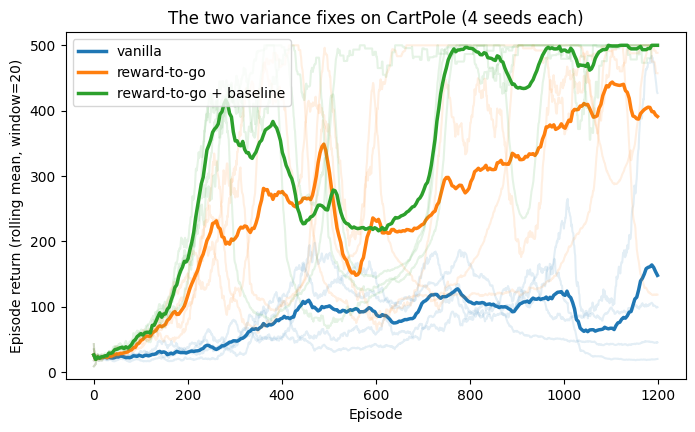

In [31]:
plt.figure(figsize=(8, 4.5))
for (name, _), color in zip(variants.items(), ["C0", "C1", "C2"]):
    plot_seed_curves([[(ep, r) for ep, _, r in h] for h in sweep_results[name]],
                     color=color, label=name, seed_alpha=0.12)
plt.xlabel("Episode")
plt.ylabel("Episode return (rolling mean, window=20)")
plt.title("The two variance fixes on CartPole (4 seeds each)")
plt.ylim(-10, 520)
plt.legend(loc="upper left")
plt.show()

The ordering we measured with histograms is now an ordering of learning curves. Reward-to-go clearly beats whole-episode weighting, and the baseline stabilizes it further, with the full configuration reaching the 500 ceiling and largely staying there while vanilla is still struggling.

Same environment, same network, same number of episodes, same expected gradient, **different noise levels**.

## The Payoff: Continuous Actions

CartPole has two actions. This is not why we need policy gradient. Let's look at an environment where DQN cannot even be written down on paper, one with infinite actions. We keep it deliberately tiny, because we want to *watch the policy converge as a distribution*, and for that the entire policy must fit in one plot: a 1-D state on the x-axis, a 1-D action on the y-axis. (No standard gymnasium environment has a 1-D observation, Pendulum has 3 and MountainCarContinuous has 2, and both bring their own complications, so once more we build the microscope ourselves.)

**AimEnv.** Each episode is a single shot: observe a position $x \sim U[-1, 1]$, choose a real-valued action $a$, receive reward $-(a - f(x))^2$, done. The target function $f$ is smooth and nonlinear. The optimal policy is simply $\mu^*(x) = f(x)$ with zero spread, but the agent does not know $f$. It only ever sees scalar rewards.

In [32]:
class AimEnv(gym.Env):
    """Observe x, pick a real number a, get reward -(a - f(x))^2. One step."""

    def __init__(self):
        super().__init__()
        self.observation_space = spaces.Box(-1.0, 1.0, shape=(1,), dtype=np.float32)
        self.action_space = spaces.Box(-np.inf, np.inf, shape=(1,), dtype=np.float32)
        self.x = None

    @staticmethod
    def f(x):
        return np.sin(2 * x) + 0.5 * x

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.x = self.np_random.uniform(-1.0, 1.0)
        return np.array([self.x], dtype=np.float32), {}

    def step(self, action):
        r = -(float(action[0]) - self.f(self.x)) ** 2
        return np.array([self.x], dtype=np.float32), r, True, False, {}

### Same algorithm, different distribution

Here is the beautiful part: **we change nothing**!
- `make_policy` choose the fitting distribution for the environment: `GaussianPolicy` for a `Box` action space.
- `collect_episode` collects episode samples and scores exactly as before.
- `train_reinforce_full` runs exactly the same.

The enumeration that DQN could not perform simply never appears, the policy outputs an action instead of ranking all of them.

For the Gaussian, the score function even has a closed form worth staring at:

$$\nabla_{\mu} \log \pi(a \mid s) = \frac{a - \mu(s)}{\sigma^2}.$$

The gradient points from the current mean **toward the sampled action**. Multiply by a positive weight (better than baseline) and the mean moves toward what it just did; multiply by a negative weight and it moves away. Trial-and-error in one formula. And $\sigma$ is a learned parameter like any other: the policy tunes *its own exploration*.

In [33]:
aim_env = AimEnv()

set_seed(0)
aim_policy = make_policy(aim_env)          # a GaussianPolicy, picked automatically

# train in chunks so we can photograph the policy as it learns
checkpoint_iters = [0, 10, 25, 50, 100, 200, 400]
xs_grid = np.linspace(-1, 1, 101, dtype=np.float32)

def snapshot(policy):
    # evaluate mu(x) and sigma on a grid of states, without gradients
    with torch.no_grad():
        dist = policy(torch.from_numpy(xs_grid).unsqueeze(1))
        return dist.mean.squeeze().numpy().copy(), float(dist.stddev[0])

aim_snapshots = {0: snapshot(aim_policy)}
for prev, upto in zip(checkpoint_iters[:-1], checkpoint_iters[1:]):
    train_reinforce_full(aim_env, n_iters=upto - prev, batch_size=64, lr=1e-2,
                         baseline=True, seed=prev, policy=aim_policy)
    aim_snapshots[upto] = snapshot(aim_policy)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

### Watching a policy converge

In [34]:
from utils import plot_aim_policy

@interact(iteration=checkpoint_iters)
def show_aim_snapshot(iteration=0):
    mu, sigma = aim_snapshots[iteration]
    plt.figure(figsize=(7.5, 4.2))
    plot_aim_policy(xs_grid, mu, sigma, AimEnv.f(xs_grid),
                    title=f"Gaussian policy after {iteration} iterations "
                          f"($\\sigma = {sigma:.2f}$)")
    plt.show()

interactive(children=(Dropdown(description='iteration', options=(0, 10, 25, 50, 100, 200, 400), value=0), Outp…

Scrub through the checkpoints. At iteration 0 the band is wide and flat: the policy knows nothing and tries everything, that width *is* its exploration. As training proceeds the mean $\mu_\theta(x)$ bends onto the hidden target curve $f(x)$, a function the agent has never seen, reconstructed from scalar rewards alone, and the band tightens around it: having found what pays, the policy stops experimenting. Exploration was not scheduled as in DQN, it was **learned away**, because increasing $\sigma$ near a good mean mostly samples worse actions with negative (baselined) weights, so the gradient on $\log \sigma$ turns negative on its own.

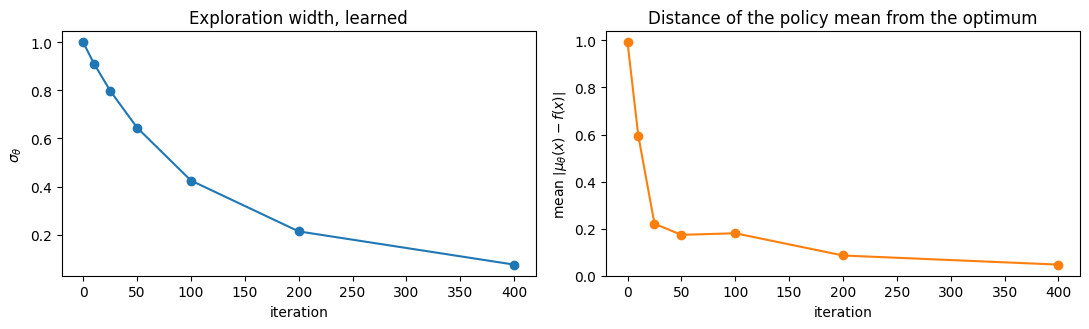

In [35]:
sigmas = [aim_snapshots[it][1] for it in checkpoint_iters]
errors = [np.abs(aim_snapshots[it][0] - AimEnv.f(xs_grid)).mean() for it in checkpoint_iters]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(checkpoint_iters, sigmas, "o-", color="C0")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel(r"$\sigma_\theta$")
axes[0].set_title("Exploration width, learned")
axes[1].plot(checkpoint_iters, errors, "o-", color="C1")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel(r"mean $\left| \mu_{\theta}(x) - f(x) \right|$")
axes[1].set_title("Distance of the policy mean from the optimum")
plt.tight_layout()
plt.show()

_Question_. Is there any danger in letting the policy control its own exploration?

### Scaling up (Pendulum)

AimEnv had one step per episode. Pendulum, the environment that opened this tutorial, is the real thing: swing a rod upright and hold it there, 200 steps per episode, dense negative rewards (roughly $-16$ at hanging down to $0$ when balanced upright), returns in the $[-1600, 0]$ range. We throw our full REINFORCE at it, with both fixes plus the two practical knobs it needs: weight normalization (the raw reward scale is in the thousands) and a discount $\gamma = 0.95$ inside the reward-to-go, which shortens the effective credit-assignment horizon.

Loaded cached Pendulum runs from cache/pendulum.pkl


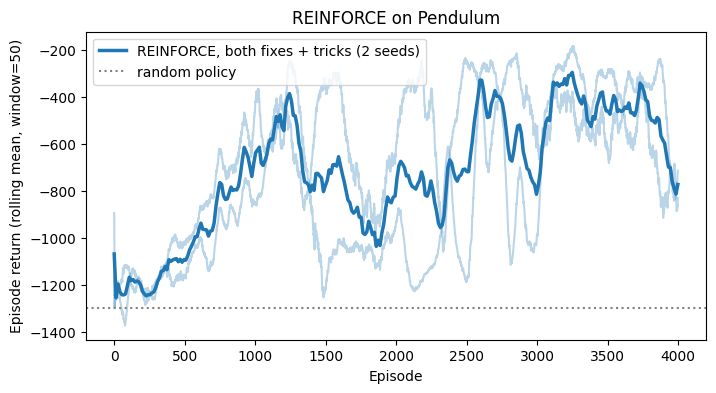

In [36]:
def run_pendulum():
    return [train_reinforce_full(gym.make("Pendulum-v1"), n_iters=250, batch_size=16,
                                 lr=1e-2, gamma=0.95, reward_to_go=True,
                                 baseline=True, normalize=True, seed=s)[0]
            for s in tqdm(range(2), desc="pendulum seeds")]

pendulum_runs = load_or_run(cache_dir / "pendulum.pkl", run_pendulum, desc="Pendulum runs")

plt.figure(figsize=(8, 4))
plot_seed_curves([[(ep, r) for ep, _, r in h] for h in pendulum_runs],
                 window=50, color="C0", label="REINFORCE, both fixes + tricks (2 seeds)")
plt.axhline(-1300, color="gray", linestyle=":", label="random policy")
plt.xlabel("Episode")
plt.ylabel("Episode return (rolling mean, window=50)")
plt.title("REINFORCE on Pendulum")
plt.legend(loc="upper left")
plt.show()

The policy improves substantially over random, so pure Monte Carlo policy gradient *can* do continuous control, which is the point of the section. But a limitation is revealed: it took **thousands of episodes** to get partway, the two seeds disagree, and progress is anything but monotone. Our fixes reduced the variance of an estimator whose weights are still full Monte Carlo returns, 200 steps of accumulated noise per episode.

## The Cost: On-Policy Sample Inefficiency

Now for the bill. Remember the step we circled in red in the REINFORCE algorithm box: *discard the batch and collect a fresh one*. The derivation forces this. The boxed formula is an expectation over trajectories drawn from **the current policy** $\pi_\theta$; the moment we take a gradient step, $\theta$ changes and every stored trajectory becomes a sample from the *wrong* distribution. Methods with this property are called **on-policy**: each sample is used for exactly one gradient step and then thrown away.

Contrast this with DQN, which is **off-policy**: its replay buffer holds transitions from many old policies and reuses each of them dozens of times, and Q-learning's update is valid regardless of which policy produced the transition. That difference should be worth a lot. Let's measure how much.

### REINFORCE vs DQN at equal environment steps

Let's compare our REINFORCE algorithm with DQN on the larger **LunarLander** environment. Both sides arrive with their best effort: DQN uses exactly the configuration that solved LunarLander in the previous tutorial (replay buffer, decaying exploration, target network), and REINFORCE gets everything this tutorial built (reward-to-go with a discount, the baseline, weight normalization).

**NOTE**: the fair x-axis is **environment steps**, not episodes. An episode is not a unit of cost, and REINFORCE consumes several episodes per update.

Loaded cached LunarLander comparison from cache/lunar_dqn_vs_reinforce.pkl


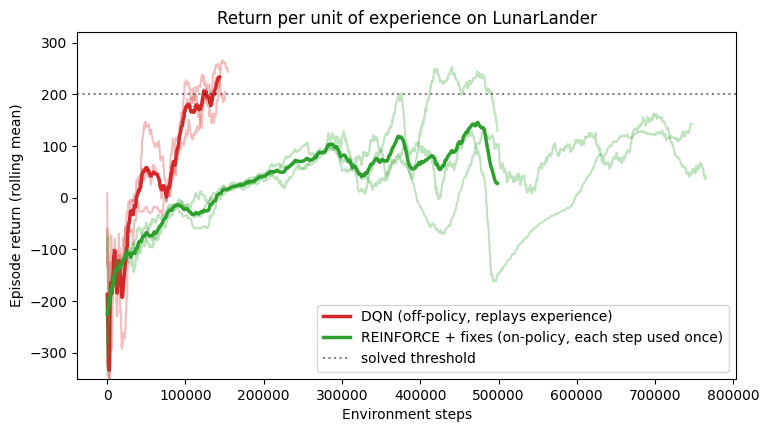

In [37]:
from utils import train_dqn

def run_lunar_comparison():
    # DQN: Tut07's LunarLander configuration, verbatim
    dqn = [train_dqn(gym.make("LunarLander-v3"), n_episodes=400, gamma=0.99, lr=5e-4,
                     hidden_dim=128, eps_start=1.0, eps_end=0.05, eps_decay_episodes=300,
                     buffer_size=50_000, warmup=1000, batch_size=64, target_sync_freq=500,
                     seed=s, progress=tqdm)[0]
           for s in range(3)]
    # REINFORCE: both fixes plus the practical knobs from the Pendulum section
    reinforce = [train_reinforce_full(gym.make("LunarLander-v3"), n_iters=250, batch_size=8,
                                      lr=5e-3, gamma=0.99, reward_to_go=True,
                                      baseline=True, normalize=True, seed=s)[0]
                 for s in tqdm(range(3), desc="REINFORCE seeds")]
    return {"DQN": dqn, "REINFORCE": reinforce}

lunar_results = load_or_run(cache_dir / "lunar_dqn_vs_reinforce.pkl", run_lunar_comparison,
                            desc="LunarLander comparison")

plt.figure(figsize=(8.5, 4.5))
plot_seed_curves([[(steps, r) for steps, r in h] for h in lunar_results["DQN"]],
                 color="C3", label="DQN (off-policy, replays experience)")
plot_seed_curves([[(steps, r) for _, steps, r in h] for h in lunar_results["REINFORCE"]],
                 window=50, color="C2", label="REINFORCE + fixes (on-policy, each step used once)")
plt.axhline(200, color="k", linestyle=":", alpha=0.5, label="solved threshold")
plt.xlabel("Environment steps")
plt.ylabel("Episode return (rolling mean)")
plt.title("Return per unit of experience on LunarLander")
plt.ylim(-350, 320)
plt.legend(loc="lower right")
plt.show()

The picture narrates itself. DQN crosses the solved threshold within $130$k steps of experience on every seed and finishes there. REINFORCE is genuinely learning, it climbs from $\approx -150$ well into positive returns, so the fixes are visibly doing their job, but after three quarters of a million steps, **five times DQN's entire training run**, none of its seeds ends anywhere near a reliable landing; the best of them briefly grazes the threshold around $400$k steps only to collapse back, and progress is anything but monotone.

The structural reason is the data economics. Every transition DQN collects lands in the buffer and is drawn into on the order of sixty minibatch updates before it is evicted. REINFORCE monetizes each transition exactly once and burns it. And LunarLander is exactly the environment where that difference bites: the transitions that carry the learning signal, the rare near-landings, are replayed by DQN across thousands of gradient steps, while REINFORCE glances at each of them once and throws it away. The harder experience is to obtain (sparse rewards, long horizons, a physical robot, a paying user), the more each discarded transition costs.

### An easy fix: add a replay buffer

So let's just steal the buffer. Back on our smaller CartPole environment, let's store every step's state, action, and reward-to-go. At each iteration, we will sample a minibatch from the buffer and apply the identical policy-gradient update, scoring the stored actions with the current policy's log-probabilities, mechanically, exactly what DQN does with its buffer.

In [38]:
from collections import deque

def collect_episode_raw(env, policy, seed=None):
    # like collect_episode, but returns raw (states, actions, rewards)
    # so transitions can be stored and re-scored later
    obs, _ = env.reset(seed=seed)
    states, actions, rewards = [], [], []
    done = False
    while not done:
        with torch.no_grad():
            dist = policy(torch.as_tensor(obs, dtype=torch.float32))
            a = int(dist.sample().item())
        states.append(np.asarray(obs, dtype=np.float32))
        actions.append(a)
        obs, r, term, trun, _ = env.step(a)
        rewards.append(float(r))
        done = term or trun
    return states, actions, rewards


def train_reinforce_buffer(env, n_iters=150, batch_size=8, lr=5e-3,
                           buffer_size=20_000, updates_per_iter=4, minibatch=256,
                           seed=0):
    set_seed(seed)
    policy = make_policy(env)
    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)
    buffer = deque(maxlen=buffer_size)          # CHANGED: the replay buffer

    history = []
    env_steps = 0
    for it in tqdm(range(n_iters), leave=False):
        # collect the same number of fresh episodes as before...
        for ep in range(batch_size):
            states, actions, rewards = collect_episode_raw(env, policy, seed=seed + len(history))
            env_steps += len(rewards)
            history.append((len(history), env_steps, sum(rewards)))
            for s, a, w in zip(states, actions, rewards_to_go(rewards)):
                buffer.append((s, a, w))        # CHANGED: store instead of using once

        # ...but update from buffer samples, scored by the CURRENT policy
        for _ in range(updates_per_iter):
            idx = np.random.randint(len(buffer), size=min(minibatch, len(buffer)))
            s = torch.as_tensor(np.stack([buffer[i][0] for i in idx]))
            a = torch.as_tensor(np.array([buffer[i][1] for i in idx]))
            w = torch.as_tensor(np.array([buffer[i][2] for i in idx], dtype=np.float32))
            w = w - w.mean()                    # same constant baseline as before
            dist = policy(s)
            loss = -(dist.log_prob(a) * w).mean()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    return history, policy

### Running PG with a replay buffer

Loaded cached buffered REINFORCE runs from cache/buffer_reinforce.pkl


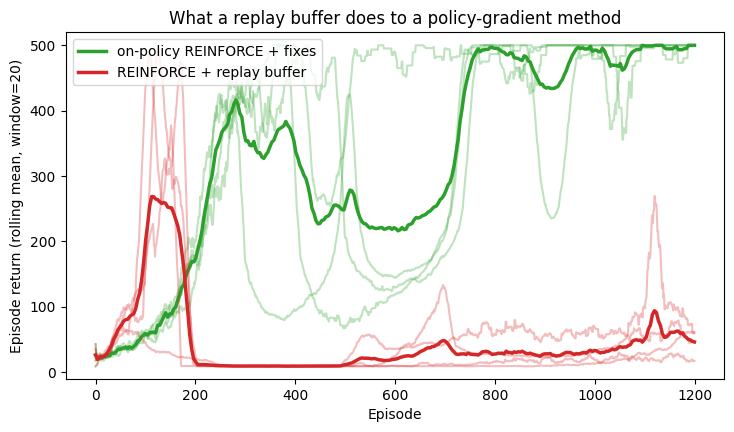

In [39]:
buffered_runs = load_or_run(
    cache_dir / "buffer_reinforce.pkl",
    lambda: [train_reinforce_buffer(gym.make("CartPole-v1"), seed=s)[0]
             for s in tqdm(range(n_seeds), desc="buffered REINFORCE")],
    desc="buffered REINFORCE runs",
)

plt.figure(figsize=(8.5, 4.5))
plot_seed_curves([[(ep, r) for ep, _, r in h]
                  for h in sweep_results["reward-to-go + baseline"]],
                 color="C2", label="on-policy REINFORCE + fixes")
plot_seed_curves([[(ep, r) for ep, _, r in h] for h in buffered_runs],
                 color="C3", label="REINFORCE + replay buffer")
plt.xlabel("Episode")
plt.ylabel("Episode return (rolling mean, window=20)")
plt.title("What a replay buffer does to a policy-gradient method")
plt.ylim(-10, 520)
plt.legend(loc="upper left")
plt.show()

The buffered version starts out looking healthy, early on the buffer contains only recent, nearly on-policy data, so the update is nearly correct. Then it stalls, decays, and **collapses** to the do-nothing policy, and stays there while the on-policy version cruises at the ceiling. More reuse of data made the algorithm *worse than not learning at all*.

_Question_: Why is this happening? Point to the **exact step** that becomes invalid in the policy gradient derivation when the trajectories are sampled from an old policy $\pi_{\theta_\text{old}}$ instead of the current $\pi_\theta$.

On the very first step of the derivation, we found the gradient to be $\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}[\cdots]$. Here the expectation must be under the distribution that $\theta$ itself induces. That is what made the log-derivative trick produce $\nabla J$ rather than some other vector. Feed it samples from $\pi_{\theta_\text{old}}$ and you compute an average of the right quantity under the wrong weighting. This gives us a **biased** estimate of the gradient. Unlike variance, which averages away, bias compounds. The stale data keeps endorsing actions the current policy has already moved past, until the policy is pinned somewhere degenerate.

There is a principled correction: re-weight each stored sample by the ratio $\frac{\pi_\theta(a \mid s)}{\pi_{\theta_\text{old}}(a \mid s)}$, **importance sampling**, the classical technique whose use for off-policy evaluation in RL was developed by [Precup, Sutton & Singh (2000)](https://dl.acm.org/doi/10.5555/645529.658134). It restores unbiasedness, and the price is, of course, variance. Those ratios explode as the policies drift apart. Taming that trade is beyond the scope of this course.

### TD-learning vs Policy-Gradient (overview)

We have now seen both families fail and both families shine. The scorecard:

| | TD | PG |
| --- | --- | --- |
| Represents | $Q(s, a)$, policy implicit | $\pi_\theta$, values nowhere |
| Action spaces | discrete (needs the $\arg\max$) | discrete **and continuous** |
| Optimal stochastic policies | cannot represent the target | native |
| Exploration | bolted on ($\epsilon$-greedy schedule) | built in, learned ($\sigma_\theta$, softmax) |
| Data regime | off-policy, replays experience | on-policy, single-use samples |
| Sample efficiency (measured) | solves LunarLander within ~130k steps | not solved with 5x that experience |
| Gradient signal | biased target, low variance | unbiased, high variance |
| Convergence picture | contraction, one fixed point (tabular) | non-concave ascent, decoy attractors |

## Do We Even Need the Gradient?

Policy gradient is one member of a broader family, **policy search**: define a parametric policy, define $J(\theta)$, and optimize it *somehow*. The score-function gradient is one choice of "somehow". Here is a more naive approach: pure random search.
- Take a **linear** policy, 8 numbers, no hidden layers.
- Perturb it with Gaussian noise.
- Keep the perturbation if the return improves, discard it otherwise.

No gradients, no log-probs, no distributions.

In [40]:
def evaluate_policy(env, W, n_episodes=3, seed=0):
    # deterministic linear policy: pick the action with the larger score W @ obs
    total = 0.0
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        while not done:
            obs, r, term, trun, _ = env.step(int(np.argmax(W @ obs)))
            total += r
            done = term or trun
    return total / n_episodes


def random_search(env, n_iters=60, noise=0.5, seed=0):
    rng = np.random.default_rng(seed)
    W = np.zeros((2, 4))                          # 8 parameters. that's the whole policy
    best = evaluate_policy(env, W, seed=seed * 1000)
    history = [best]
    for it in range(1, n_iters + 1):
        W_try = W + noise * rng.normal(size=W.shape)   # perturb
        score = evaluate_policy(env, W_try, seed=seed * 1000 + it * 17)
        if score > best:                               # keep only if better
            W, best = W_try, score
        history.append(best)
    return history, W

### Evaluating random policy search

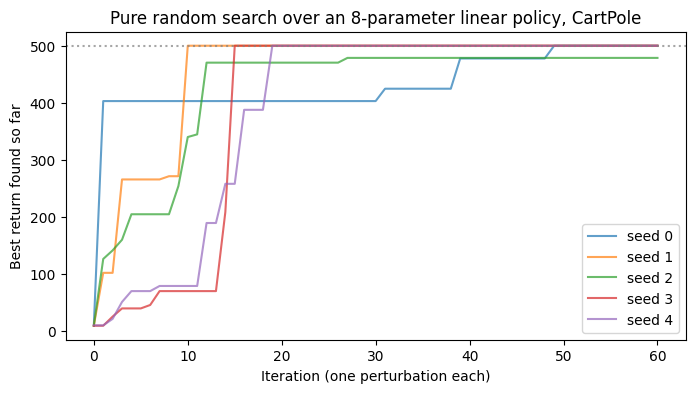

In [41]:
plt.figure(figsize=(8, 4))
for seed in range(5):
    rs_history, _ = random_search(gym.make("CartPole-v1"), seed=seed)
    plt.plot(rs_history, alpha=0.7, label=f"seed {seed}")
plt.axhline(500, color="gray", linestyle=":", alpha=0.7)
plt.xlabel("Iteration (one perturbation each)")
plt.ylabel("Best return found so far")
plt.title("Pure random search over an 8-parameter linear policy, CartPole")
plt.legend(loc="lower right")
plt.show()

Every seed solves CartPole within a few dozen perturbations, each iteration costing a handful of episodes. This is far better than our PG method and all its machinery.

### The power of gradient-free policy search

The massive improvement of this naive search over our sophisticated PG implementation is not an accident. When the parameter count is small, and the reward is informative, gradient-free search is a serious baseline. An 8-parameter policy on a dense-reward task is where it shines.

Some successful gradient-free methods:
- The cross-entropy method, a slightly smarter population version of the same idea, held the Tetris record for years ([Szita & Lorincz, 2006](https://dl.acm.org/doi/10.1162/neco.2006.18.12.2936))
- Evolution strategies were shown to be a scalable alternative to RL at industrial size ([Salimans et al., 2017](https://arxiv.org/abs/1703.03864))
- [Mania, Guy & Recht (2018)](https://proceedings.neurips.cc/paper/2018/hash/7634ea65a4e6d9041cfd3f7de18e334a-Abstract.html) showed random search over *static linear policies* is competitive on standard continuous-control benchmarks.

Why does it stop working? Dimensionality. Random search probes $J$ one whole parameter vector at a time and learns one scalar per probe; in $d$ dimensions, blind perturbations become exponentially unlikely to find ascent directions as $d$ grows, the same curse we keep meeting. Our CartPole policy network has thousands of parameters, a modern one has millions, at that scale the scalar-per-probe economics are hopeless.

## Conclusion

We made the policy the primary object and optimized it directly, and the road had a shape worth remembering.

- The **log-derivative trick** turned an un-backpropagatable objective into an expectation we can sample; the environment's dynamics dropped out of the algebra, which is *why* policy gradients are model-free.
- On **VaultEnv** we saw the price of policy space: $J(\theta)$ is non-concave, with a self-sealing decoy attractor, and where you start can decide where you end, in stark contrast with the fixed-point guarantees of Tut06. We also saw that value-based Q-learning walks through that same trap untouched.
- The estimator is **unbiased but noisy**, and we measured the noise: at our probe policy, most single-episode estimates pointed away from the true uphill. Noise turned out to change not just the speed but the *destination*.
- Two exact fixes, **reward-to-go** (causality) and a **baseline** (control variate), cut the measured variance and turned a wobbling learner into one that pins CartPole's ceiling, at zero extra sample cost.
- Stochastic policies **carry their own exploration**, and on AimEnv we watched the policy narrow its Gaussian by itself, a learned analogue of the $\epsilon$-schedule we once hand-designed.
- Continuous actions, DQN's impossibility, required changing *one line*, which distribution the network parameterizes.
- The price is **on-policy data**: on LunarLander, DQN solved the task within roughly $130$k environment steps while REINFORCE, handed five times that experience, was still far from a reliable landing. And the obvious buffer hack does not just underperform, it corrupts the gradient and collapses, because the derivation's very first line demands fresh data.
- And a cheerful memento mori: on small, dense problems, **random search** beats all of it.

**Where this leaves us.** Value-based methods brought sample efficiency, off-policy reuse, and low-variance (if biased) signals, but enumerate actions and bolt exploration on. Policy-based methods handle any action space and explore natively, but pay full price for data and ride a noisy gradient across a treacherous landscape. These strengths interlock so neatly that the conclusion writes itself, and the loose thread of the baseline is exactly where the seam will go.

The larger lesson is the one this course keeps returning to: planning, value learning, and policy learning are not rival sects, they are components, and the strongest known decision-makers are built from all three.